# 01 — Exploratory Data Analysis & Preprocessing

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')


## 1. Load Data

In [2]:

# Read column names (one per line, no index prefix)
with open('data/census-bureau.columns') as f:
    cols = [line.strip() for line in f if line.strip()]

df = pd.read_csv('data/census-bureau.data', header=None, names=cols)
print(f"Shape: {df.shape}")
df.head(3)


Shape: (199523, 42)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.


## 2. Basic Info

In [3]:

print(df.dtypes)
print("\nNumerical columns:")
num_cols = df.select_dtypes(include='number').columns.tolist()
print(num_cols)


age                                             int64
class of worker                                object
detailed industry recode                        int64
detailed occupation recode                      int64
education                                      object
wage per hour                                   int64
enroll in edu inst last wk                     object
marital stat                                   object
major industry code                            object
major occupation code                          object
race                                           object
hispanic origin                                object
sex                                            object
member of a labor union                        object
reason for unemployment                        object
full or part time employment stat              object
capital gains                                   int64
capital losses                                  int64
dividends from stocks       

In [4]:

# Replace '?' with NaN
df.replace(' ?', np.nan, inplace=True)
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing)
print(f"\nTotal columns with missing: {len(missing)}")


Missing values per column:
migration code-change in msa      99696
migration code-move within reg    99696
migration code-change in reg      99696
migration prev res in sunbelt     99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
hispanic origin                     874
state of previous residence         708
dtype: int64

Total columns with missing: 9


## 3. Label Distribution

Raw counts:
label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

Weighted counts (representative of population):
label
- 50000.    3.250046e+08
50000+.     2.224125e+07
Name: weight, dtype: float64

Weighted % earning >50K: 6.4%


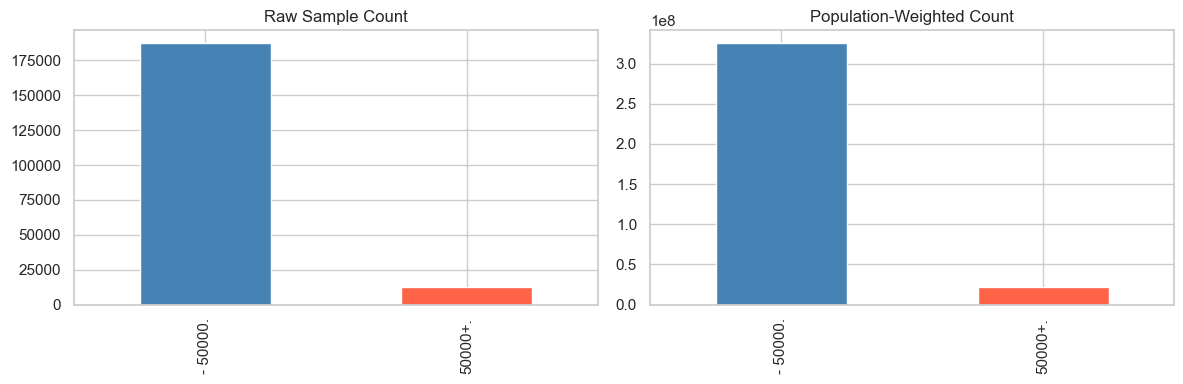

Class imbalance ratio: 15.1 :1


In [5]:

label_col = 'label'
df[label_col] = df[label_col].str.strip()

label_counts = df[label_col].value_counts()
print("Raw counts:")
print(label_counts)

# Weighted distribution
weight_col = 'weight'
weighted = df.groupby(label_col)[weight_col].sum()
print("\nWeighted counts (representative of population):")
print(weighted)
print(f"\nWeighted % earning >50K: {weighted['50000+.'] / weighted.sum() * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Raw Sample Count')
axes[0].set_xlabel('')
weighted.plot(kind='bar', ax=axes[1], color=['steelblue','tomato'])
axes[1].set_title('Population-Weighted Count')
axes[1].set_xlabel('')
plt.tight_layout()
plt.savefig('figures/fig_label_dist.png', dpi=100)
plt.show()
print("Class imbalance ratio:", round(label_counts.iloc[0]/label_counts.iloc[1], 1), ":1")


## 4. Numerical Features

In [6]:

num_features = [c for c in num_cols if c not in ['weight']]
print("Numerical features:", num_features)
df[num_features].describe().round(2)


Numerical features: ['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year', 'year']


,age,detailed industry recode,detailed occupation recode,wage per hour,capital gains,capital losses,dividends from stocks,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,year
count,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.0
mean,34.49,15.35,11.31,55.43,434.72,37.31,197.53,1.96,0.18,1.51,23.17,94.5
std,22.31,18.07,14.45,274.90,4697.53,271.90,1984.16,2.37,0.55,0.85,24.41,0.5
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,94.0
25%,15.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,94.0
50%,33.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,2.00,8.00,94.0
75%,50.00,33.00,26.00,0.00,0.00,0.00,0.00,4.00,0.00,2.00,52.00,95.0
max,90.00,51.00,46.00,9999.00,99999.00,4608.00,99999.00,6.00,2.00,2.00,52.00,95.0


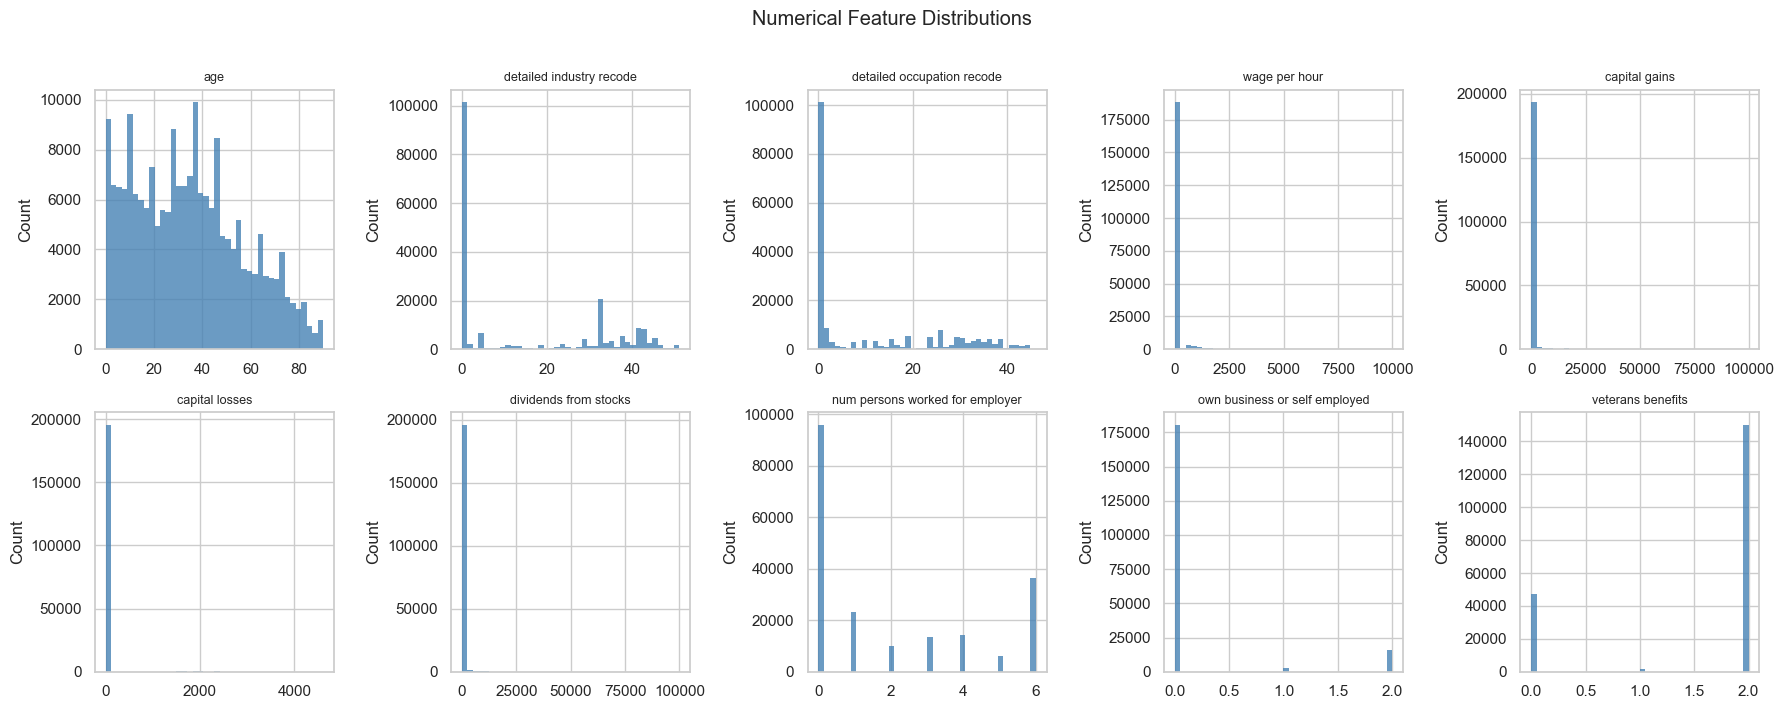

In [7]:

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(num_features[:10]):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Count')
plt.suptitle('Numerical Feature Distributions', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_num_dist.png', dpi=100)
plt.show()


## 5. Key Categorical Features

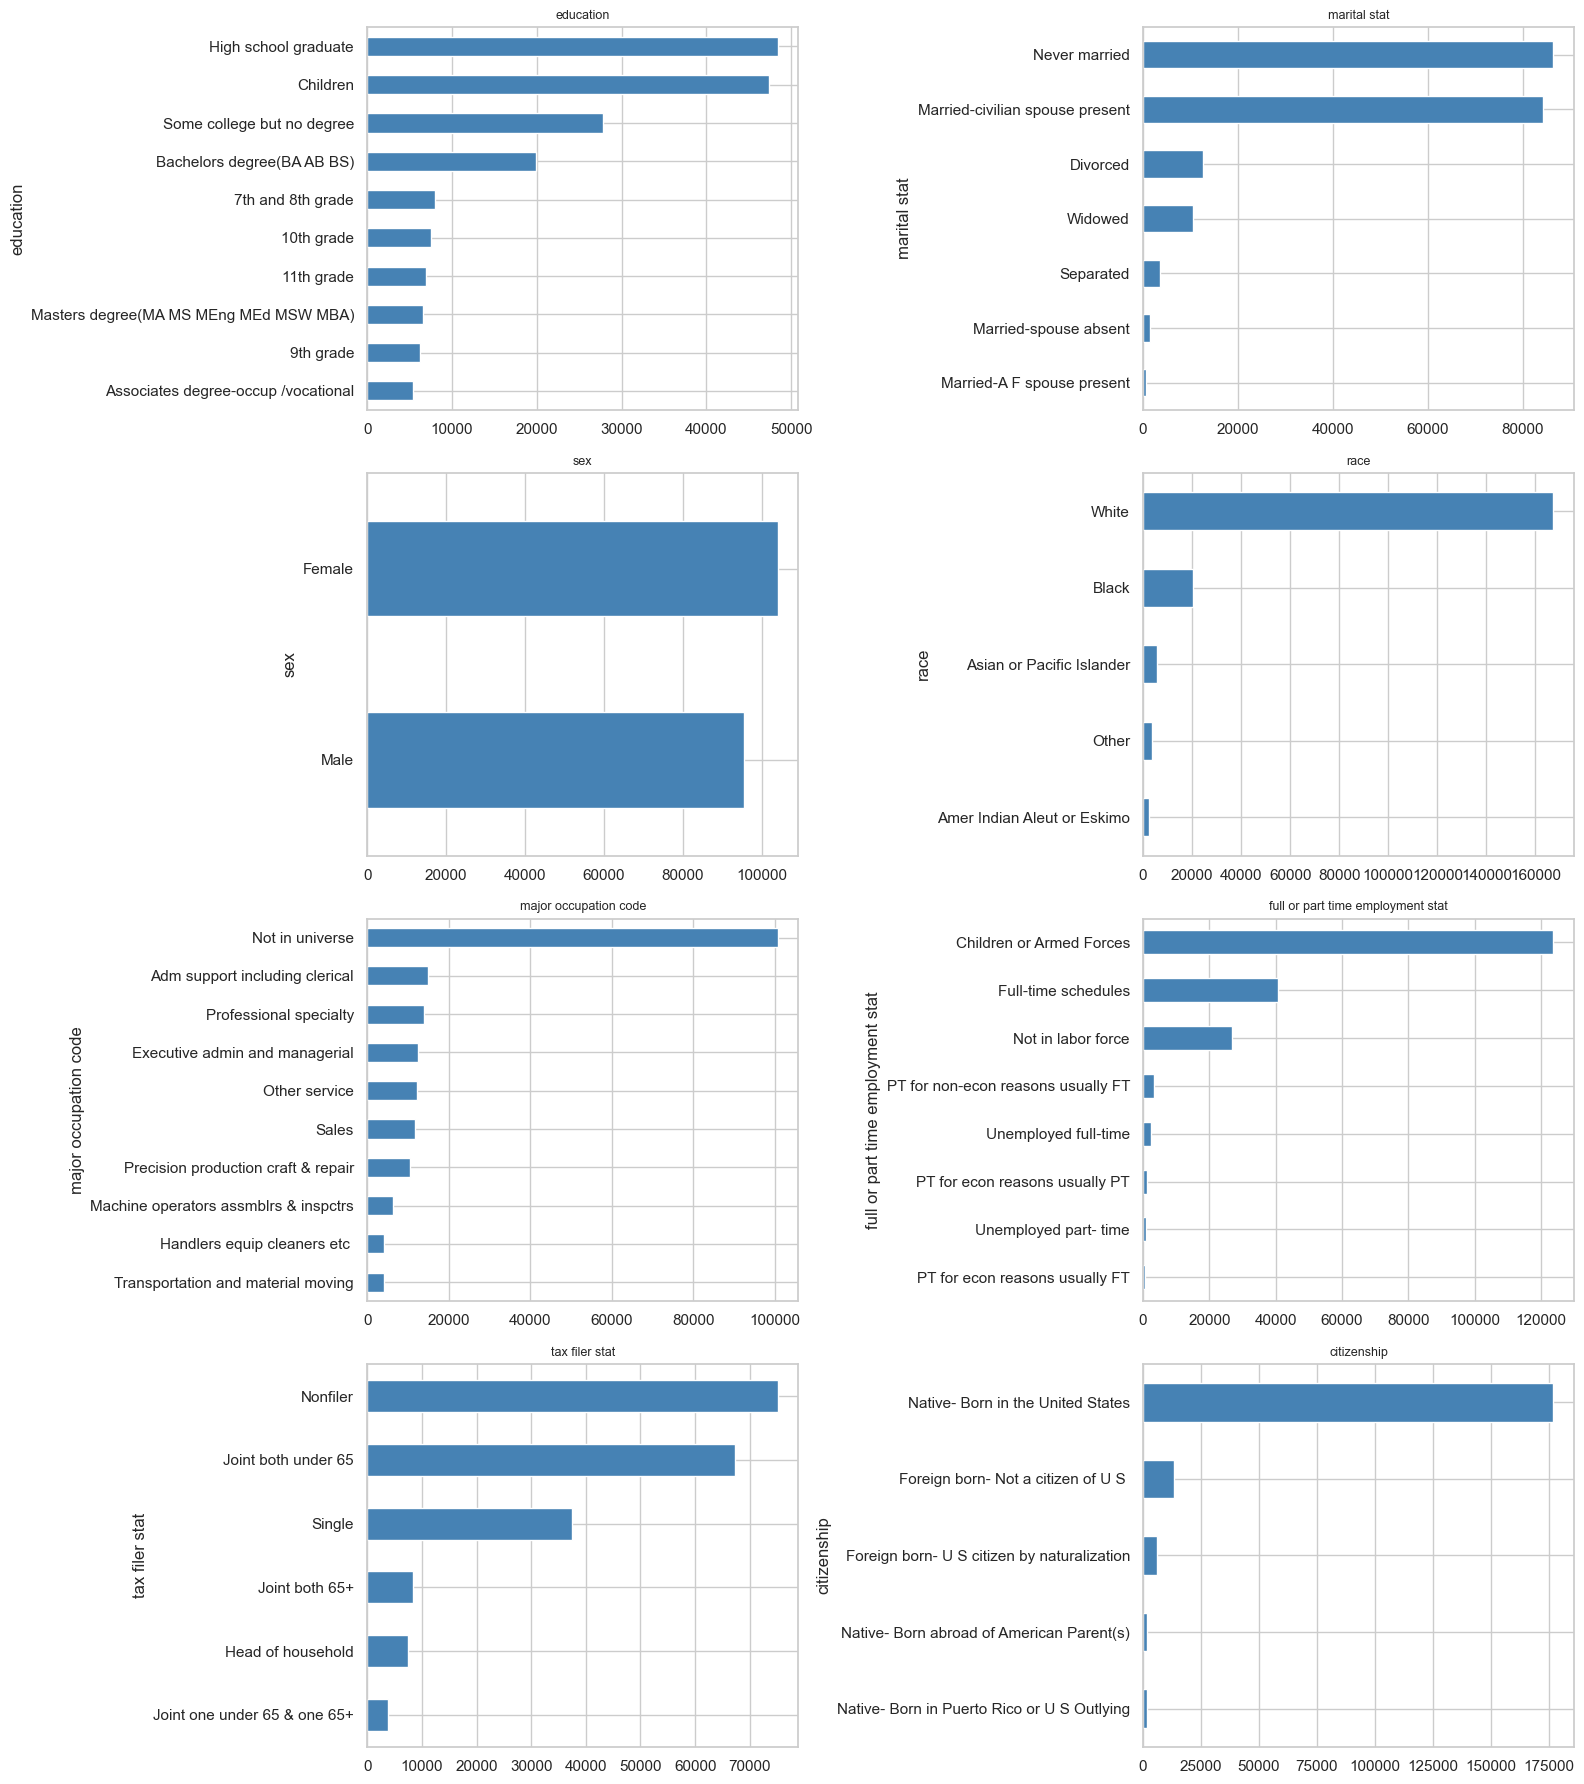

In [8]:

key_cats = ['education', 'marital stat', 'sex', 'race', 'major occupation code',
            'full or part time employment stat', 'tax filer stat', 'citizenship']

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()
for i, col in enumerate(key_cats):
    counts = df[col].value_counts().head(10)
    counts.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=9)
    axes[i].invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig_cat_dist.png', dpi=100)
plt.show()


## 6. Feature vs Label

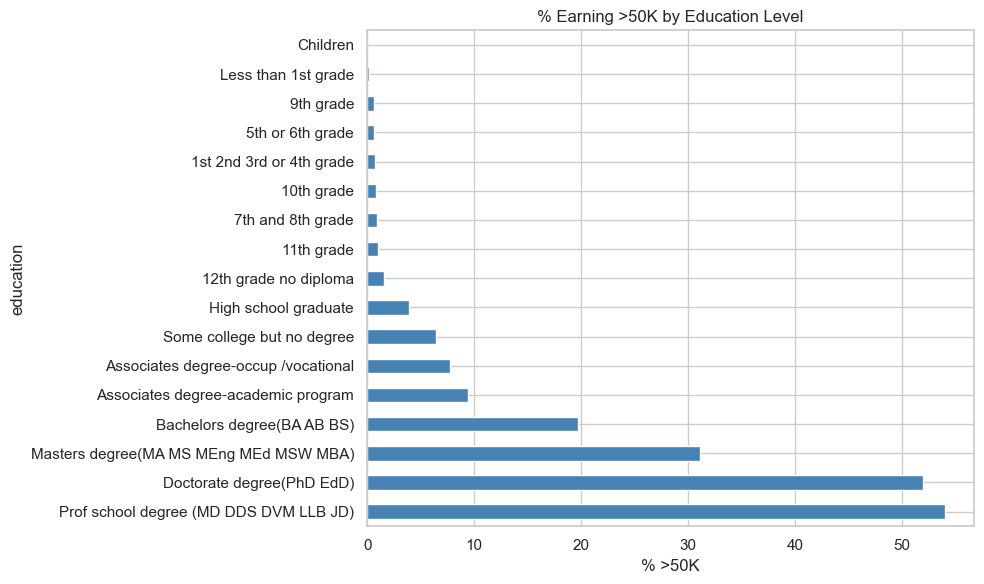

In [9]:

# Income rate by education
edu_income = df.groupby('education')[label_col].apply(
    lambda x: (x == '50000+.').mean() * 100
).sort_values(ascending=False)
edu_income.plot(kind='barh', color='steelblue', figsize=(10, 6))
plt.title('% Earning >50K by Education Level')
plt.xlabel('% >50K')
plt.tight_layout()
plt.savefig('figures/fig_edu_income.png', dpi=100)
plt.show()


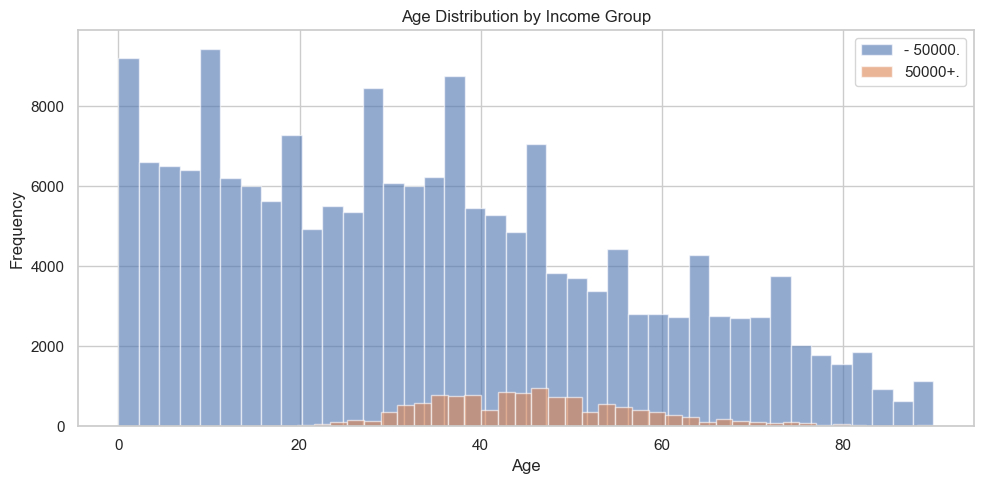

In [10]:

# Age distribution by label
df_plot = df[['age', label_col]].dropna()
df_plot.groupby(label_col)['age'].plot(kind='hist', bins=40, alpha=0.6, legend=True)
plt.title('Age Distribution by Income Group')
plt.xlabel('Age')
plt.tight_layout()
plt.savefig('figures/fig_age_income.png', dpi=100)
plt.show()


## 7. Correlation (Numerical)

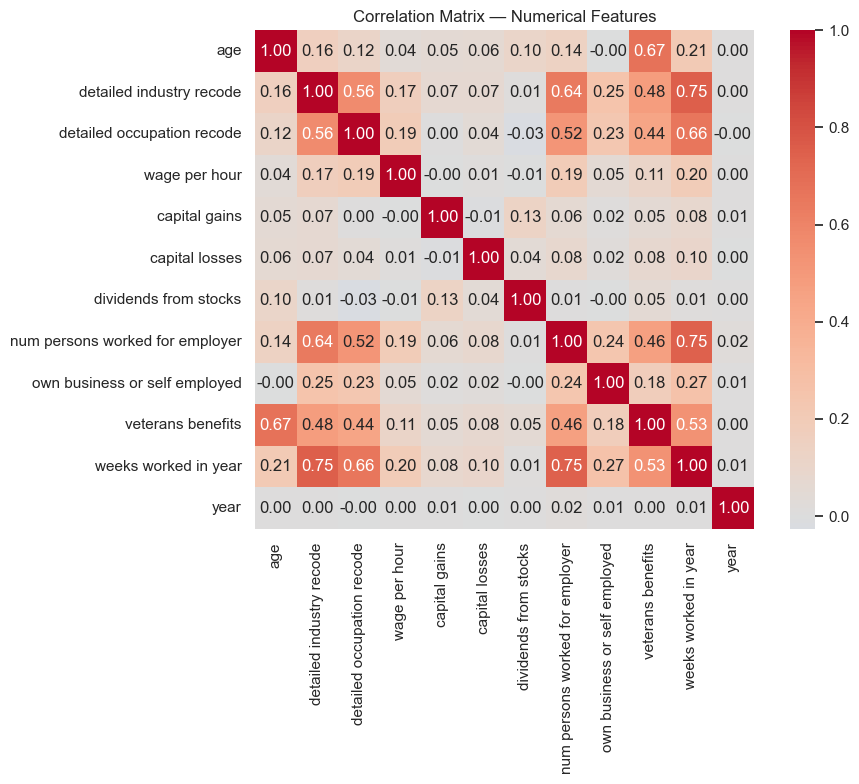

In [11]:

corr = df[num_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.savefig('figures/fig_corr.png', dpi=100)
plt.show()


## 8. Preprocessing & Save

In [12]:

from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

# Binary label
df_clean['label_binary'] = (df_clean[label_col] == '50000+.').astype(int)
df_clean.drop(columns=[label_col], inplace=True)

# Identify column types
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_feat_cols = [c for c in df_clean.select_dtypes(include='number').columns
                 if c not in ['weight', 'label_binary']]

print(f"Categorical columns: {len(cat_cols)}")
print(f"Numerical feature columns: {len(num_feat_cols)}")

# Fill missing
for c in num_feat_cols:
    df_clean[c].fillna(df_clean[c].median(), inplace=True)
for c in cat_cols:
    df_clean[c].fillna(df_clean[c].mode()[0], inplace=True)

# Label encode categoricals
le = LabelEncoder()
for c in cat_cols:
    df_clean[c] = le.fit_transform(df_clean[c].astype(str))

print("\nFinal shape:", df_clean.shape)
print("Missing values remaining:", df_clean.isnull().sum().sum())
df_clean.head(3)


Categorical columns: 28
Numerical feature columns: 12

Final shape: (199523, 42)
Missing values remaining: 0


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label_binary
0,73,3,0,0,12,0,2,6,14,6,...,39,39,39,4,0,1,2,0,95,0
1,58,6,4,34,16,0,2,0,4,8,...,39,39,39,4,0,1,2,52,94,0
2,18,3,0,0,0,0,1,4,14,6,...,40,40,40,0,0,1,2,0,95,0


In [13]:

df_clean.to_csv('data/census_preprocessed.csv', index=False)
print("Saved: census_preprocessed.csv")
print("Columns:", list(df_clean.columns))


Saved: census_preprocessed.csv
Columns: ['age', 'class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'wage per hour', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'weight', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's adm